# Immo Eliza: Data Analysis

## Cleaning Data: brainstorm
**Big picture plan =>>  Raw -> Clean -> Explore -> Questions & Answers **

- ✅ Json -> csv.

##### Importing libraries and data file
- ✅ Importing data file, Import pandas, , matplotlib

### Raw : Getting a feel for the data
- Get a feel for the data:
  - ✅ have a look in data wrangler.
  - ✅ have a look at it with .info() .describe() .size(), .shape(), etc...
  - Visualizing here too? no... 


### Raw -> Clean : Identify problems
- Before Cleaning: 
  - ✅ what sorts of questions will I want to answer? Rough idea. 

- Check for the following problems/situations :
  - ✅ Removing empty rows.
  - ✅ percentage of missing values per column : deliverable + usefull 
  - ✅ Duplicates : dropped
  - Outliers? .describe() + box plots
  - ✅ Data type of all columns : fixed
  - ✅ Data health : calculated and visualized. `data_health` and `data_health_by_type`
  
- - Data pruning/cleaning:
  - Decide for low health columns, wheter to drop/fill/prune some rows
  - clean up spaces 
  - Are there columns that clearly should be removed?


❗- Export to clean_dataset.csv

- **REMARKS ON NULLS:**
  The exercise readme demands no empty values. I choose to ignore that. Here's why:
    - We collected a lof of rows. If we dropped all the rows that have *some* empty values, we would drop every row.
    - Some columns only make sense for some type of properties: `land_area` only makes sense for houses,  but it makes *a lot* of sense for houses. We clearly should not drop that column, but simply ignore for apartments price analysis. The same goes for `has_elevator`: most houses don't, and won't mention it.
    - For some columns, a null value can be infered as a False. `has_swimming_pool` is the best example: if you're selling a house with a swimming pool, you're going to mention that. In this case, a null is almost certainly a False. 
    - Having lots of null is a bad metric for the health of this data set, as the above three points show. 




### Explore : Visualize the Clean Data
- start with a recount
- basic correlations rough pass
- add a dataframe by zipcode dataframe for slicing data finely?
- add columns like square mete


Correlations — price vs variables, variable vs variable, sort them
Histograms / visualizations — surface area, price distributions, regional breakdowns
Summary stats — most/least expensive by region, avg/median/price per m²



### Questions & Answers

- Decide what analysis to run:
  - What questions do i want to answer?
  - What are the most relevant factors?
  - What do I want to see?



## Stated objectives from the exercise readme:

### Cleaning:
- No duplicates
- No blank spaces (ex: `" I love python "` => `"I love python"`)
- No errors
- No empty values

### Analysis:
Use the tools such as `matplotlib`/`seaborn`/`plotly`!
Answer the following questions with a vizualization if appropriate:

- How many rows and columns?
- What is the correlation between the variables and the price? (Why might that be?)
- How are variables correlated to each other? (Why?)
- Which variables have the greatest influence on the price?
- Which variables have the least influence on the price?
- How many qualitative and quantitative variables are there? How would you transform these values into numerical values?
- Percentage of missing values per column?


### Data Interpretation

After analyzing your data, it's finally time to interpret your results. You have to communicate your analysis using simple words and a table or graph, then use the results to decide on your best course of action.

Example of questions you should be able to answer to:

\*NB: This is a non-exhaustive list. Try to make a maximum of interpretations of the dataset.
**Bonus points from yours truly for creative and outside the box questions that you answer.\***

You **must** be able to answer :

- Plot the outliers.
- Which variables would you delete and why ?
- Represent the number of properties according to their surface using a histogram.
- In your opinion, which 5 variables are the most important and why?
- What are the **most** expensive municipalities in Belgium? (Average price, median price, price per square meter)
- What are the **most** expensive municipalities in Wallonia? (Average price, median price, price per square meter)
- What are the **most** expensive municipalities in Flanders? (Average price, median price, price per square meter)
- What are the **less** expensive municipalities in Belgium? (Average price, median price, price per square meter)
- What are the **less** expensive municipalities in Wallonia? (Average price, median price, price per square meter)
- What are the **less** expensive municipalities in Flanders? (Average price, median price, price per square meter)

### Deliverables

As a deliverable, we expected a compelling presentation that tells a story from the data.

Your code should be clean, structured and documented as always.

1. Pimp up the README file:
   - Description
   - Installation
   - Usage
   - (Visuals)
   - (Contributors)
   - (Timeline)
   - (Personal situation)

#### Plots must-have
- Title
- Legend
- Axis labels (do not forget units)
- Correct usage of colors
- Comparable scales
- No overlapping text
- No screenshots

#### Evaluation criteria

| Criteria       | Indicator                                                                                                     | Yes/No |
| -------------- | ------------------------------------------------------------------------------------------------------------- | ------ |
| 1. Is complete | Know how to answer all the above questions.                                                                   |        |
|                | Use `pandas` and `matplotlib`/`seaborn`                                                                       |        |
|                | Nice presentation on the subject                                                                              |        |
|                | Code is clean and structured                                                                                  |        |
|                | README is complete and nicely formatted                                                                       |        |
| 2. Is great    | Additional questions were answered.                                                                           |        |
|                | Bonus was answered.                                                                                           |        |
|                | The [colors are chosen carefully.](https://chartio.com/learn/charts/how-to-choose-colors-data-visualization/) |        |

##### Imports

In [1]:
## Imports we'll need

import json
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default') # seaborn, ggplot
import matplotlib.cm as cm

#It tells Pandas: "Stop using 'e' notation 
# and just show me two decimal places for all floats."
pd.options.display.float_format = '{:,.2f}'.format


# %matplotlib inline

### Importing the file we'll use:
data_file = '../data/all_properties_data_wip.csv'


In [2]:
## Function to turn a jsonl to a csv

def turn_a_jsonl_to_csv(input_file_path, output_file_path):
    with open(input_file_path, "r") as input_file:
        rows = [json.loads(line) for line in input_file if line.strip()]
    

    with open(output_file_path, "w", newline="") as output_file:
        fieldnames = rows[0].keys()   
        writer = csv.DictWriter(output_file, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow(row)
            
# turn_a_jsonl_to_csv('./data/output_files/all_properties_data_improved_backup.jsonl','./data/output_files/all_properties_data_improved_backup.csv')

### Raw Data: Getting the feel for it data:
#### From Data wrangler :
- Lots of listing are completely empty : anything with an empty zip code should be removed.

lots of missing values on : kitchen equipment, garden area, has swimming pool, has cellar, number of garages, is low energy has solar panel has floor heating, has heat pump, has fireplace, has balcony, has attic, yearly_total_primary_energy_consumption_in_kWh_by_year.
    > check how many garden area are missing in garden area is true.
    > presumably, if has garage is true and num of garage is none, num of garage is 1


#### What I learned:
- We have 29543 entries, 37 columns. 
- df.dtypes -> booleans are not recognised as bools
- We have 76 duplicates
- 
#### What was done
-> columns_names is a list of all column names


#### Problems for later:
- data health by column.
- change data type of booleans to booleans, check the rest


In [3]:
df = pd.read_csv(data_file)
columns_names = df.columns.tolist() ## puting column names into a list, maybe we can iterate on it later.
#df.info()      # -> 29543 entries, 37 columns
#df.dtypes      # booleans are not recognised as bools, string are objects.
#df.describe()  # Numerical outliers are: price, num of bedrooms, liveable surface area, terrace area, garden area, land area, build year 2028?, num of garages 2024? specific and yearly energy
df.isnull().sum() # lots of missing values


page_id                                                       0
page_url                                                      0
locality                                                   1122
zip_code                                                   1122
property_type                                              1122
property_subtype                                           1122
price                                                      1122
number_of_bedrooms                                         2128
livable_surface_m2                                         1122
kitchen_equipment                                         20181
furnished                                                 13859
has_terrace                                                3977
terrace_area_m2                                           18684
has_garden                                                 4632
garden_area_m2                                            23306
land_area_m2                            

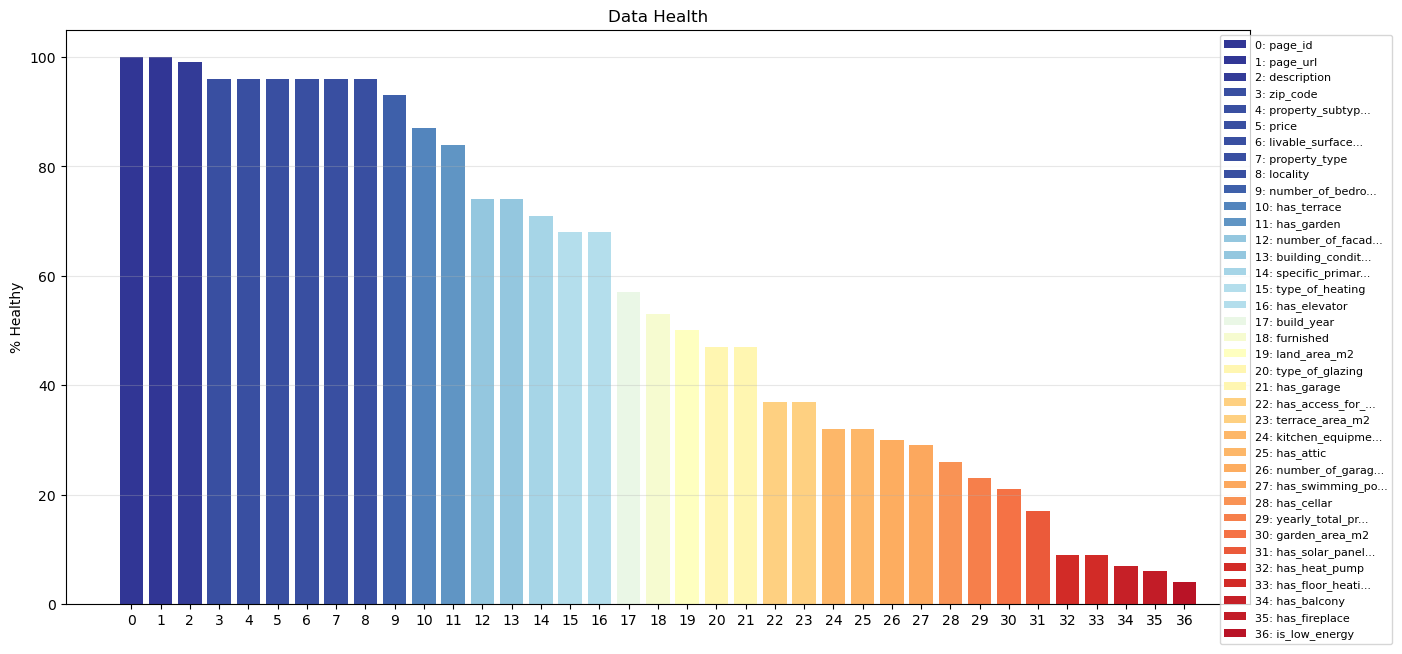

In [4]:
## Visualizing health_data
data_health = (100-(df.isna().mean()*100)).round().sort_values(ascending=False)

## Working on colors:
cmap = plt.get_cmap('RdYlBu') # get the colormap into a variable.
norm = plt.Normalize(vmin=0, vmax=100) # normalise the values for the colormap
colors = cmap(norm(data_health.values)) # sets colors as the color map, on the normalise values, on the values

## Setting the stage of the graph.
fig, ax = plt.subplots(figsize=(14,7),)
labels = [label[:15]+"..." if len(label) > 15 else label for label in data_health.index]
labels_num = list(range(len(data_health.index)))
legends = []
for i in range(len(labels)):
    legends.append(f"{i}: {labels[i]}")

    


### Building the graph
bars = ax.bar(data_health.index, data_health.values, color=colors ) #color='coolwarm' # color="plasma"
ax.set_title("Data Health")
ax.set_ylabel("% Healthy")
ax.grid(True, alpha=0.3, axis="y")
ax.set_xticks(range(len(data_health.index)))
ax.set_xticklabels(labels_num)
ax.legend(bars, legends, loc="upper right", bbox_to_anchor=(1.125, 1), fontsize=8, frameon=True)

plt.xticks()
plt.tight_layout()
plt.show()

### Raw -> clean
0/ What questions will i want to ask?
    - What drives prices up/down?
    - Why is the data spotty? any similarities between the low health columns?



**1/ Duplicates:**
First the obvious and easy: Removing duplicates and empty rows
    -> 76 duplicates were dropped
    -> 1119 entries with no data removed
    -> 105 duplicated url were dropped 
    
    ==> 28244 cleaner entries left

❗ Should temporarly drop page_id and page_url then drop duplicates.


**2/ Data types:**
- 15 columns should be booleans, but are not because of nulls. 
    -> 15 columns set to boolean + boolean_columns is a list of boolean columns
- 11 columns should be strings but were not. Some just because, others, like zip_code were int, so there were treated as numerical. 
    -> 11 columns set to strings

**3/ Filling in some blanks**
    - in the obvious places, values were filled in : 
     -> garages, elevator, swimming pool are null unless stated otherwise.
❗ might need a check

**4/ Dropping useless columns**
- Dropped 14 columns
❗ I might have to undo some of that for the machine learning

**5/ Outliers:**
- Nuke some outliers
❗ I might have to undo some of that for the machine learning

**6/ Data Health:**
Examined data health in total and by property type:
  - -> Created data_health, the average of missing values per columns **! High number = Healthy !**
  - -> data_health_by_type, the same grouped by type of properties **! High number = Healthy !**
🧠 Lots of differences in data health by types of properties



In [5]:
df['livable_surface_m2'].isnull().sum()

np.int64(1122)

In [6]:
# 1/ Removing duplicates, empty rows, and bad rows:
#df.duplicated().sum() # 76 duplicates

df = df.drop_duplicates() # 29467 entries left after duplicates drop


## Removing rows that are missing critical information:
df = df.dropna(subset=['zip_code']) # 1119 removed -> 28348 entries left
df = df.dropna(subset=['price']) # empty prices are useless
df = df.dropna(subset=['livable_surface_m2']) 



# Removing duplicated urls. 
df = df.drop_duplicates(subset=["page_url"])
df = df[df["page_id"] != "21010"]


## When looking at outliers, I spotted some properties that existed twice under different urls.

# We drop page_id and page urls temporarily
df_temp = df.drop(['page_id', 'page_url'], axis=1)
# df_temp.duplicated().sum() # found 480 duplicates are indeed found

# we create a mask to pick what to take and leave
mask = ~df_temp.duplicated() # we create a mask of trues and false, but ~flipped, so the false are to be dropped later
#print(mask) # this shows a series of trues and false
df = df.loc[mask].reset_index(drop=True) # df.loc[maks] only takes the trues from the mask (so drops the falses)


df.shape


(27972, 37)

In [7]:
## 2/ Setting Data Types 
# Setting booleans to booleans
#df.dtypes # checking data types
#df['furnished'].unique() # this column should be bool, but isn't, because of nulls

# Reassigning the boolean columns as a boolean type
list_of_columns_to_change_into_bools = ['furnished', 'has_terrace', 'has_garden', 'has_swimming_pool', 'has_cellar', 'has_garage', 'has_elevator', 'has_access_for_disabled', 'is_low_energy', 'has_solar_panels', 'has_floor_heating', 'has_heat_pump', 'has_fireplace', 'has_balcony', 'has_attic']
boolean_columns = list_of_columns_to_change_into_bools

for column in list_of_columns_to_change_into_bools:
    df[column] = df[column].astype('boolean')

# Assigning strings to categorical columns:
string_columns = ['page_id', 'page_url', 'locality', 'zip_code', 'property_type',
       'property_subtype', 'kitchen_equipment', 'building_condition', 'type_of_heating', 'type_of_glazing', 'description']

for column in string_columns:
    df[column] = df[column].astype('string')

# df.info() # it worked

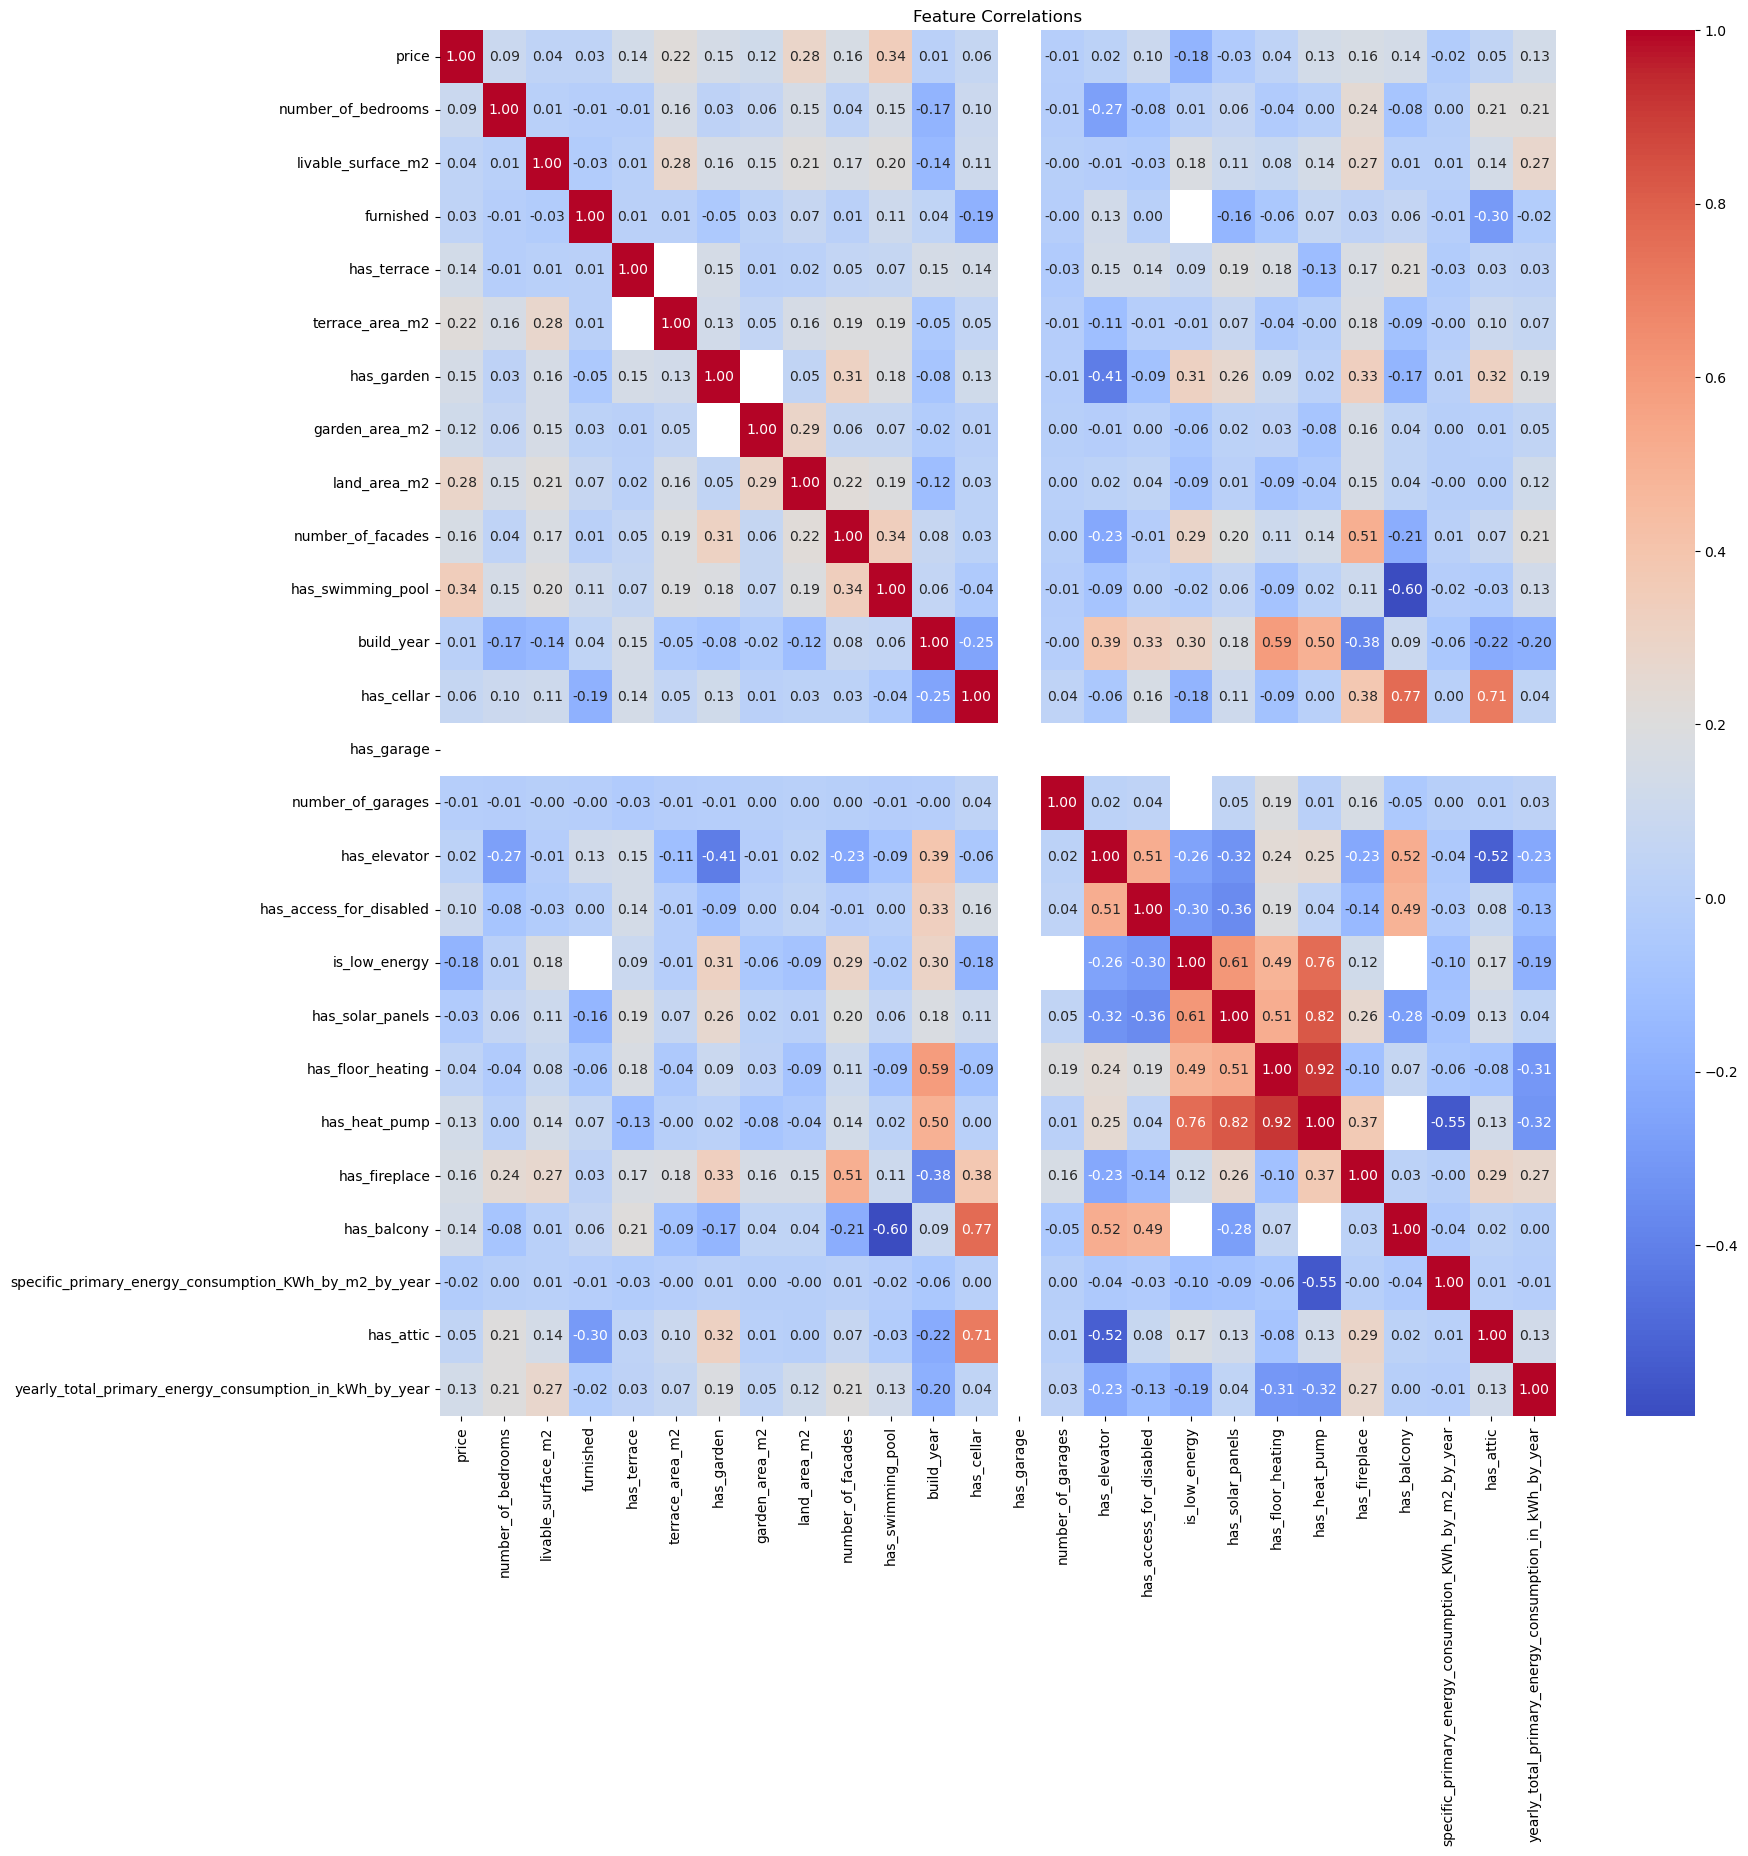

In [8]:
## corr matrix to get an idea
corr_matrix = df.corr(numeric_only=True)
#print(corr_matrix.sort_values)
plt.figure(figsize=(18,18))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlations")
plt.show()

In [9]:

## 3/ Filling in some blanks

## Garages
# If it has a number of garages, it has a garage
df.loc[df["number_of_garages"] >= 1, "has_garage"] = True

# has_garage: None -> False
df["has_garage"] = df["has_garage"].fillna(False)

# if has_garage == True and number_of_garages is NaN -> 1
df.loc[(df["has_garage"] == True) & (df["number_of_garages"].isna()), "number_of_garages"] = 1

# if has_garage == False -> number_of_garages = 0
df.loc[df["has_garage"] == False, "number_of_garages"] = 0

# garden
df["has_garden"] = df["has_garden"].fillna(False)


# Elevator: if has_elevator is null, -> False
df.loc[(df["has_elevator"].isna()), "has_elevator"] = False

# Swimming Pool: if has_swimming_pool is null, -> False
df.loc[(df["has_swimming_pool"].isna()), "has_swimming_pool"] = False


## if furnished > kitchen is fully equipped. 
# >> no need, we're dropping kitchen equipment anyway



In [10]:
## 4/ Dropping useless columns & Renaming energy

columns_to_drop = ['has_access_for_disabled', 'terrace_area_m2', 'kitchen_equipment', 'has_access_for_disabled', 
                   'has_attic', 'has_cellar', 'yearly_total_primary_energy_consumption_in_kWh_by_year', 
                   'garden_area_m2', 'has_solar_panels', 'has_heat_pump', 'has_floor_heating', 'has_balcony', 'has_fireplace', 'is_low_energy', 'description',]

## ❗❗ Dropping descriptions for now

df = df.drop(columns_to_drop, axis=1)
print(len(columns_to_drop))

15


In [11]:
## 5/ Outliers : let's nuke ourselves some outliers
# Drop a set of rows: df = df[df["property_type"] != "investmentProperty"]
# drop by page_id : df = df[df["page_id"] != 12345]


### Cleaning property types:
df = df[df["property_type"] != "investmentProperty"] ## Drop investments properties

# Targeted nuking
df.loc[(df['number_of_garages'] == 79), "number_of_garages"] = 1
df.loc[(df['number_of_garages'] >100 ), "number_of_garages"] = np.nan 

### Price
df.loc[df["price"] <= 1000, "price"] = np.nan 
df.loc[df["price"] >= 5_000_000, "price"] = np.nan 
df = df.dropna(subset=['price'])            # when creating new nulls, i need to nuke these rows, otherwise, i'm creating nulls



### Number of Bedrooms:
df.loc[df["page_id"] == "19694", "number_of_bedrooms"] = np.nan 
df.loc[df["number_of_bedrooms"] == 0, "number_of_bedrooms"] = np.nan

#### Liveable surface livable_surface_m2
df.loc[df["page_id"] == "5392", "livable_surface_m2"] = np.nan
df.loc[df["livable_surface_m2"] < 10, "livable_surface_m2"] = np.nan
df = df.dropna(subset=['livable_surface_m2'])                # when creating new null, i need to nuke these rows, otherwise, i'm creating nulls

## Terrace area  terrace_area_m2
#df.loc[df["terrace_area_m2"] > 1000, "terrace_area_m2"] = np.nan 

## garden_area_m2
#df.loc[df["garden_area_m2"] > 150000, "garden_area_m2"] = np.nan ## dropped already

## land_area_m2
df.loc[df["land_area_m2"] < 10, "land_area_m2"] = np.nan

## specific_primary_energy_consumption_KWh_by_m2_by_year
df.loc[df["specific_primary_energy_consumption_KWh_by_m2_by_year"] > 2000, "specific_primary_energy_consumption_KWh_by_m2_by_year"] = 2000



# Targeted nuking
df.loc[(df['number_of_garages'] == 79), "number_of_garages"] = 1
df.loc[(df['number_of_garages'] >100 ), "number_of_garages"] = np.nan 





In [12]:
df['price'].sort_values(ascending=False)


26135   4,990,000.00
2467    4,980,000.00
4974    4,950,000.00
4973    4,950,000.00
8967    4,600,000.00
            ...     
15938      14,999.00
6538       10,000.00
16949      10,000.00
2579        2,500.00
11391       1,100.00
Name: price, Length: 24443, dtype: float64

In [13]:
# Renaming energy column, Sorting studentHouse type into appartments type

df['energy_KWh_m2_year'] = df['specific_primary_energy_consumption_KWh_by_m2_by_year']
df = df.drop('specific_primary_energy_consumption_KWh_by_m2_by_year', axis=1)
#df[(df['property_type'] == "appartment" )]  = (df['property_type'] == 'studentHouse')

df.loc[df['property_type'] == 'studentHouse', 'property_type'] = 'appartment'

#(df['property_type'] == 'studentHouse')] = "appartment"

In [14]:
## 6/ Data Health :
# df.isna().sum() # we have some nulls, of course
data_health = (100-(df.isna().mean()*100)).round().sort_values(ascending=False)
#data_health

data_health_by_type = df.groupby('property_type').apply(lambda g: 100-(g.isna().mean() * 100), include_groups=False) # include groups is because of a deprecations warning.
#data_health_by_type

#data_health_by_type.sort_values(by="appartment", axis=1, ascending=True)

#total_entries = len(df)
#print(total_entries)
#data_health2 = (100-((df.isna().sum())/total_entries*100)).round().sort_values(ascending=False)
#data_health2



In [15]:
## Vizualizing health data by type: for later


### Explore Data

- **Creating a regions columns:**
    Based on zipcode, needed for some analysis

- **Recount** : 26655 rows, 24 columns 

- **Visualizing health_data**
    Examined data health in total and by property type:
    - -> Created data_health, the average of missing values per columns **! High number = Healthy !**
    - -> data_health_by_type, the same grouped by type of properties **! High number = Healthy !**


- **Distributions**


- **Correlations**


In [16]:
## Adding a region and price_by_m2 column

## Creating a regions columns:
def set_region(zip_code):
    if "1000" <= zip_code <= "1299":
        return "Brussels"
    elif ("1300" <= zip_code <= "1499") or ("4000" <= zip_code <= "7999"):
        return "Wallonia"
    else:
        return "Flanders"
    
df['region'] = df['zip_code'].apply(set_region)

## price by m2 column
df['price_by_m2'] = ((df['price']) / (df['livable_surface_m2'])).round(2)

# trimming outliers from Price by m2
df = df[df['price_by_m2'] <= 20000]


In [17]:
## Adding a "building_state" column for numerical state of the building, instead of building condition

# Redifine under construction -> new, and "to be renovated" -> "to renovate"
df.loc[(df['building_condition'] == 'Under construction'), 'building_condition'] = 'New'
df.loc[(df['building_condition'] == 'To be renovated'), 'building_condition'] = 'To renovate'

# We create a dict to map "condition" to "state"
building_condition_old = {'1' :'To demolish', "2" : 'To renovate', "3" : 'To restore', '4' : 'Normal', '5' : 'Excellent', '6' : 'Fully renovated' , '7' : 'New'}
# then realise it's much easier to go from key to value than the opposite...
building_condition = {v: k for k, v in building_condition_old.items()} 

# This maps a string condition to a numerical state:
def set_building_state(condition):
    for state in building_condition:
        try:
            return building_condition[condition]
        except:
            continue
    
#set_building_state()

# this defines a new column, mapping numerical values with from above
df['building_state'] = df['building_condition'].apply(set_building_state)

# Setting the column type as float, instead of object.
df['building_state'] = df['building_state'].astype('float')

# dropping the now useles 'building_condition' column
df = df.drop('building_condition', axis=1) 


In [18]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 24441 entries, 0 to 27971
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   page_id             24441 non-null  string 
 1   page_url            24441 non-null  string 
 2   locality            24441 non-null  string 
 3   zip_code            24441 non-null  string 
 4   property_type       24441 non-null  string 
 5   property_subtype    24441 non-null  string 
 6   price               24441 non-null  float64
 7   number_of_bedrooms  23884 non-null  float64
 8   livable_surface_m2  24441 non-null  float64
 9   furnished           14859 non-null  boolean
 10  has_terrace         22847 non-null  boolean
 11  has_garden          24441 non-null  boolean
 12  land_area_m2        12555 non-null  float64
 13  number_of_facades   18899 non-null  float64
 14  has_swimming_pool   24441 non-null  boolean
 15  build_year          14976 non-null  float64
 16  has_garag

In [19]:
# Last tweaks

## Dropping Page id and page url
df = df.drop(['page_id', 'page_url'], axis=1)


# Assigning strings to categorical columns:
df = df.reset_index(drop=True)  # drop=True avoids the old index becoming a column#


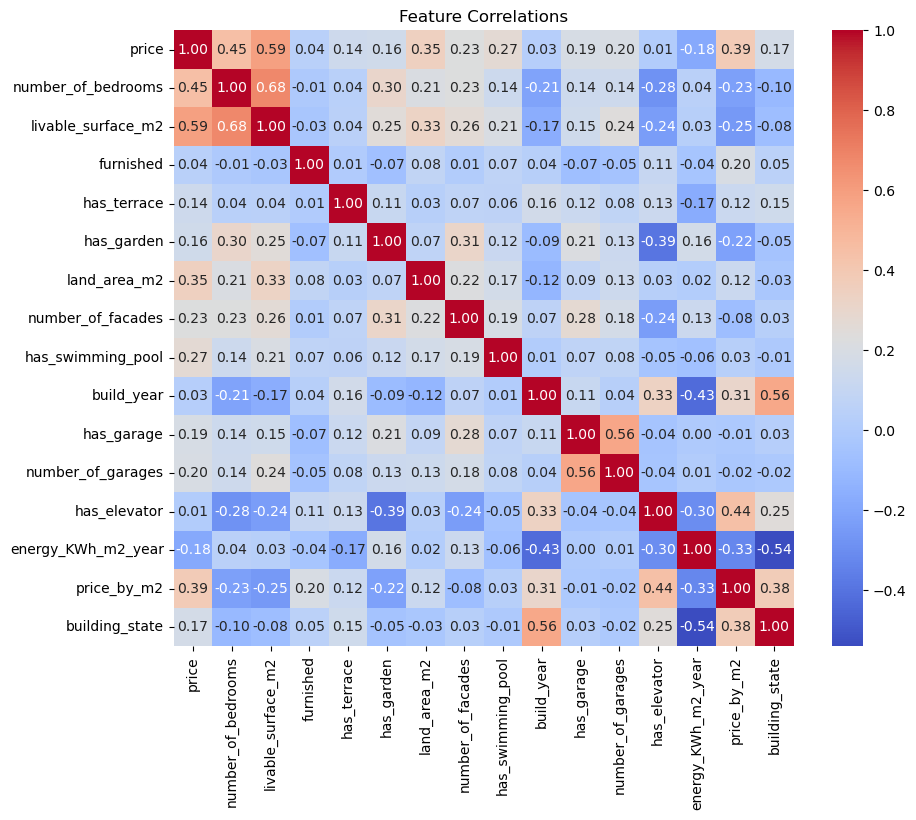

In [20]:
corr_matrix = df.corr(numeric_only=True)
#print(corr_matrix.sort_values)
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Feature Correlations")
plt.show()

In [21]:
## Expporting file
df.to_csv("clean_data_for_analysis.csv", index=False)  # saves without the row index
